In [2]:
import re
from collections import defaultdict
import json
from nltk.collocations import BigramCollocationFinder
from nltk.metrics import BigramAssocMeasures
from collections import Counter
from nltk import ngrams
import pandas as pd
import json
from scipy.stats import linregress
import matplotlib.pyplot as plt
import numpy as np

def tokenize(text):
    text = text.lower()
    words = re.findall(r'\b\w+\b', text)
    return words

def generate_ngrams(tokens, n):
    return ['_'.join(gram) for gram in ngrams(tokens, n)]

with open("tvpl_congvan_chunked.json", "r", encoding="utf-8") as f:
    data = json.load(f)


In [6]:

all_unigrams = []
for doc in data:
    tokens = tokenize(doc["chunk_content"])
    all_unigrams.extend(tokens)


unigram_counter = Counter(all_unigrams)

total_unigrams = sum(unigram_counter.values())

unigram_df = pd.DataFrame({
    'token': list(unigram_counter.keys()),
    'frequency': list(unigram_counter.values())
})

unigram_df['probability'] = unigram_df['frequency'] / total_unigrams

unigram_df['rank'] = unigram_df['frequency'].rank(method='dense', ascending=False).astype(int)

unigram_df = unigram_df.sort_values('rank').reset_index(drop=True)
unigram_df.head(20)


,token,frequency,probability,rank
0,và,1463021,0.015085,1
1,các,1443651,0.014885,2
2,của,1156052,0.011920,3
3,định,1020599,0.010523,4
4,công,845767,0.008720,5
5,có,807914,0.008330,6
6,the,685205,0.007065,7
7,bộ,657049,0.006775,8
8,được,639916,0.006598,9
9,điều,593347,0.006118,10


In [8]:
unigram_df.tail(20)

,token,frequency,probability,rank
253179,w9501502,1,1.031056e-08,3704
253180,w720110,1,1.031056e-08,3704
253181,w600,1,1.031056e-08,3704
253182,28900077,1,1.031056e-08,3704
253183,28900089,1,1.031056e-08,3704
253184,1transmitters,1,1.031056e-08,3704
253185,igranting,1,1.031056e-08,3704
253186,descriptionfee,1,1.031056e-08,3704
253187,28900090,1,1.031056e-08,3704
253188,28900106,1,1.031056e-08,3704


In [7]:
all_bigrams = []
for doc in data:
    tokens = tokenize(doc["chunk_content"])
    all_bigrams.extend(generate_ngrams(tokens, 2))

bigram_counter = Counter(all_bigrams)
total_bigrams = sum(bigram_counter.values())

bigram_df = pd.DataFrame({
    'bigram': list(bigram_counter.keys()),
    'frequency': list(bigram_counter.values())
})
bigram_df['probability'] = bigram_df['frequency'] / total_bigrams
bigram_df['rank'] = bigram_df['frequency'].rank(method='dense', ascending=False).astype(int)
bigram_df = bigram_df.sort_values('rank').reset_index(drop=True)
bigram_df.head(20)


MemoryError: 

In [3]:
all_trigrams = []
for doc in data:
    tokens = tokenize(doc["chunk_content"])
    all_trigrams.extend(generate_ngrams(tokens, 3))

trigram_counter = Counter(all_trigrams)
total_trigrams = sum(trigram_counter.values())

trigram_df = pd.DataFrame({
    'trigram': list(trigram_counter.keys()),
    'frequency': list(trigram_counter.values())
})
trigram_df['probability'] = trigram_df['frequency'] / total_trigrams
trigram_df['rank'] = trigram_df['frequency'].rank(method='dense', ascending=False).astype(int)
trigram_df = trigram_df.sort_values('rank').reset_index(drop=True)
trigram_df.head(20)


,trigram,frequency,probability,rank
0,ban_nhân_dân,155601,0.001615,1
1,theo_quy_định,115057,0.001194,2
2,ủy_ban_nhân,95887,0.000995,3
3,quy_định_tại,79666,0.000827,4
4,quy_định_của,78388,0.000814,5
5,các_cơ_quan,69749,0.000724,6
6,nhân_dân_tỉnh,65931,0.000684,7
7,uỷ_ban_nhân,59282,0.000615,8
8,có_trách_nhiệm,57700,0.000599,9
9,bộ_tài_chính,56810,0.000590,10


In [4]:
def zipf_analysis(df, label="unigram"):
    """
    Phân tích Zipf's Law cho 1 dataframe có cột 'token' và 'frequency'.
    df: pandas DataFrame gồm ít nhất 2 cột: ['token', 'frequency']
    label: tên loại n-gram (vd: 'unigram', 'bigram', 'trigram')
    """
    df = df.sort_values(by="frequency", ascending=False).reset_index(drop=True)
    df["rank"] = np.arange(1, len(df) + 1)

    log_rank = np.log10(df["rank"])
    log_freq = np.log10(df["frequency"])

    slope, intercept, r_value, p_value, std_err = linregress(log_rank, log_freq)

    alpha = -slope
    K = 10**intercept
    R2 = r_value**2

    print(f" Zipf’s Law ({label})")
    print(f"   α (slope)  = {alpha:.3f}")

    print(f"   R²          = {R2:.4f}\n")

    # plt.figure(figsize=(5,4))
    # plt.scatter(log_rank, log_freq, s=5, alpha=0.5, label="data")
    # plt.plot(log_rank, intercept + slope * log_rank, color='red', label='fit line')
    # plt.xlabel("log10(rank)")
    # plt.ylabel("log10(frequency)")
    # plt.title(f"Zipf’s Law ({label})")
    # plt.legend()
    # plt.grid(True, linestyle="--", alpha=0.4)
    # plt.show()

    return alpha, R2


In [5]:
zipf_analysis(unigram_df, label="unigram")
zipf_analysis(bigram_df, label="bigram")
zipf_analysis(trigram_df, label="trigram")

NameError: name 'unigram_df' is not defined

In [62]:
def extract_stopwords_by_zipf(unigram_df, prob_threshold=0.001):
    stopwords = unigram_df[unigram_df["probability"] > prob_threshold]["token"].tolist()
    print(f"Đề xuất {len(stopwords)} stopword (ngưỡng prob > {prob_threshold})")
    return stopwords

def remove_stopwords(tokens, stopwords):
    return [t for t in tokens if t not in stopwords]

danh_sach = extract_stopwords_by_zipf(unigram_df)
print(danh_sach)


all_tokens = []
for doc in data:
    all_tokens.extend(tokenize(doc["content_chunk"]))

clean_tokens = remove_stopwords(all_tokens, danh_sach)


Đề xuất 266 stopword (ngưỡng prob > 0.001)
['của', 'định', 'và', 'điều', 'quy', 'có', 'công', 'được', 'các', 'luật', 'cơ', 'quan', 'hợp', 'chức', 'pháp', 'nhân', 'người', 'ước', 'theo', 'tổ', 'về', 'trong', 'hành', 'quyền', 'vụ', 'cấp', 'thực', 'nhà', 'dụng', 'lý', 'hiện', 'động', 'với', 'hội', 'bảo', 'việc', 'dân', 'án', 'tại', 'trường', 'chính', 'quyết', '1', 'hoặc', '2', 'quốc', 'sản', 'ày', 'nhiệm', 'bộ', 'thông', 'cho', 'không', 'tư', 'đồng', 'quản', 'khoản', 'phải', 'tài', 'sử', 'trình', 'nghiệp', 'đối', 'thẩm', 'đầu', 'sau', 'sở', 'ban', 'doanh', 'gia', 'hoạt', 'thành', '3', 'thời', 'xã', 'chủ', 'vi', 'dự', 'hạn', 'khác', 'a', 'đất', 'kiểm', 'là', 'phạm', 'để', 'từ', 'b', 'tra', 'bản', 'kinh', 'viên', 'giao', 'nhận', 'trách', 'bị', 'c', 'sự', 'giá', 'liên', 'cá', 'xây', 'báo', 'chứng', 'hàng', 'dựng', 'phương', 'hoạch', 'an', 'thì', 'phòng', 'khi', 'tế', 'phát', 'ngày', 'dịch', 'ở', 'cầu', 'việt', 'nam', 'thuộc', 'xuất', 'kết', 'văn', 'đến', 'đại', 'giải', 'lập', 'cáo', 'tác', '

KeyboardInterrupt: 

In [ ]:
def heap_analysis(tokens, label="unigram", step=1000):
    """
    Phân tích Heap’s Law cho 1 danh sách token (list các từ hoặc cụm từ).
    tokens: list các token (vd: all_unigrams)
    label: tên loại n-gram
    step: số token mỗi lần lấy mẫu (default = 1000)
    """
    vocab_sizes = []
    token_counts = []
    seen = set()
    count = 0

    for token in tokens:
        count += 1
        seen.add(token)
        if count % step == 0:
            token_counts.append(count)
            vocab_sizes.append(len(seen))

    heap_df = pd.DataFrame({"N": token_counts, "V": vocab_sizes})

    log_N = np.log10(heap_df["N"])
    log_V = np.log10(heap_df["V"])

    slope, intercept, r_value, p_value, std_err = linregress(log_N, log_V)

    beta = slope
    K = 10**intercept
    R2 = r_value**2

    print(f"   Heap’s Law ({label})")
    print(f"   β (slope)  = {beta:.3f}")
    print(f"   K           = {K:.3f}")
    print(f"   R²          = {R2:.4f}\n")

    plt.figure(figsize=(5,4))
    plt.scatter(log_N, log_V, s=5, alpha=0.5, label="data")
    plt.plot(log_N, intercept + slope * log_N, color='red', label='fit line')
    plt.xlabel("log10(N)")
    plt.ylabel("log10(V)")
    plt.title(f"Heap’s Law ({label})")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.show()

    return beta, K, R2


   Heap’s Law (corpus_unigram)
   β (slope)  = 0.428
   K           = 14.814
   R²          = 0.9803



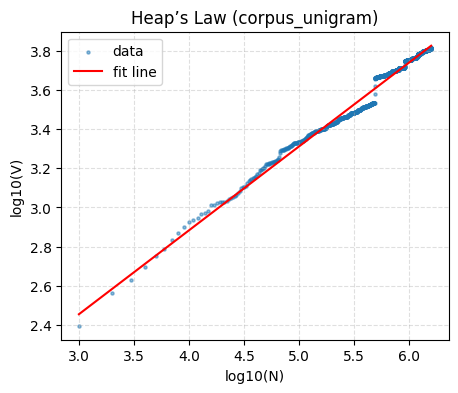

(np.float64(0.4280513008491112),
 np.float64(14.813502179160638),
 np.float64(0.9802897559145778))

In [ ]:
heap_analysis(clean_tokens, label="corpus_unigram", step=1000)


In [ ]:
inverted_index = defaultdict(lambda: defaultdict(list))

for doc in data:
    doc_id = doc["auto_id"]
    tokens = tokenize(doc["content_chunk"])
    
    for pos, token in enumerate(tokens):
        inverted_index[token][doc_id].append(pos)
    
    for pos, bg in enumerate(generate_ngrams(tokens, 2)):
        inverted_index[bg][doc_id].append(pos)
    
    for pos, tg in enumerate(generate_ngrams(tokens, 3)):
        inverted_index[tg][doc_id].append(pos)

for tokens, doc_dict in inverted_index.items():
    print(tokens, doc_dict)

KeyboardInterrupt: 